# 18 — Autoencoders: Learning Representations Without Labels

The final notebook of the deep-learning arc.

**Prerequisite:** notebook 09 (MLP) + notebook 11 (PCA) + notebook 16 (Keras basics).
**Theory used:** §6 (overfitting), §9.6 (bottleneck / representation learning).

> An **autoencoder** is a neural net trained to copy its input to its output — but
> through a **bottleneck**, a narrow hidden layer that can't hold the full input.
> Forced through that bottleneck, the net must learn a compressed **representation**
> that captures the essential structure and discards noise. No labels are used: the
> "supervision" is the input itself. This makes autoencoders the deep-learning
> analogue of PCA (notebook 11) — and, like PCA, they're a *tool* (for compression,
> denoising, anomaly detection, feature extraction) more often than an end product.
>
> This notebook builds four kinds: **undercomplete** (compression), **denoising**
> (robust features), **deep** (stacked layers), and the killer app — **anomaly
> detection** (train on normal data; anything that reconstructs badly is suspicious).
> We finish by pitting the autoencoder against plain PCA to see when the extra
> capacity pays off.

## What you'll be able to do after this notebook

1. Explain an autoencoder as **encoder + decoder + bottleneck**, and why the
 bottleneck forces representation learning (§9.6).
2. Build **undercomplete** and **denoising** autoencoders in Keras and read their
 reconstructions.
3. See the **reconstruction-error vs code-size trade-off** — the dimensionality-
 reduction curve from Wk 11, made visual.
4. Use an autoencoder for **anomaly detection** — train on one class, flag
 high-reconstruction-error outliers (the fraud/anomaly application the syllabus
 emphasizes).
5. Compare an autoencoder to **PCA** (notebook 11) — when the nonlinear AE's extra
 capacity earns its keep, and when it's overkill.
6. Recognise the **variant zoo** — sparse, contractive, variational (generative),
 and where RBMs/DBNs fit historically.

## The process

```mermaid
flowchart LR
 A["unlabelled input x"] --> B["encoder<br/>x -> code z"]
 B --> C{bottleneck<br/>dim z << dim x}
 C --> D["decoder<br/>z -> reconstruction x_hat"]
 D --> E["loss = ‖x - x_hat‖²<br/>reconstruction error"]
 E --> F["backprop updates<br/>encoder + decoder"]
 F --> B
 G["use the code z:<br/>compression / features"] -.-> C
 H["use the error:<br/>anomaly detection"] -.-> E
 style C fill:#fde,stroke:#c44e52
 style E fill:#dfd,stroke:#55a868
```

The bottleneck (red) is what makes this more than "learn the identity". The
reconstruction error (green) is both the training signal *and* a useful output.

## 1. The idea: identity under a bottleneck

A linear autoencoder (one dense layer, no nonlinearity, MSE loss) trained to
reconstruct its input is mathematically equivalent to **PCA** (notebook 11) — it
learns the same principal subspace. The whole point of the *neural* autoencoder is
the **nonlinearity**: with hidden activations, the encoder can fold the input into a
representation PCA can't reach, and the decoder unfolds it back. So an autoencoder is
"PCA, but allowed to be nonlinear" — more expressive, at the cost of more parameters
and no closed-form solution.

Let's set up Fashion-MNIST (already familiar from notebook 16) as the working data.

In [1]:
from setup import *
import os
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")
os.environ.setdefault("TF_ENABLE_ONEDNN_OPTS", "0")
import tensorflow as tf
from tensorflow import keras

# Fashion-MNIST, flattened to 784-vectors (autoencoders don't need the 2D structure).
# We keep BOTH label arrays — autoencoders train without labels, but §5's anomaly
# detection needs y_train/y_test to define "normal class" and to score detection.
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
x_train_flat = x_train.reshape(-1, 784)
x_test_flat = x_test.reshape(-1, 784)
labels = ["T-shirt","Trouser","Pullover","Dress","Coat","Sandal","Shirt",
 "Sneaker","Bag","Ankle boot"]
print(f"train {x_train_flat.shape}, test {x_test_flat.shape}, input dim = 784")

train (60000, 784), test (10000, 784), input dim = 784


### 1.1 Vocabulary (§9.6)

- **Encoder** — the part that maps input $x$ to the code $z = f(x)$. Down to the
 bottleneck.
- **Bottleneck / code** — the narrow hidden layer, dimension `code_dim` (also called
 $z$, the *latent* representation). This is where compression happens.
- **Decoder** — maps the code back to a reconstruction $\hat{x} = g(z)$, same
 dimension as the input.
- **Reconstruction error** — the loss, usually MSE: $L = \|x - \hat{x}\|^2$.
- **Undercomplete** — `code_dim < input_dim` (the normal case; the bottleneck does
 the work). *Overcomplete* (`code_dim ≥ input_dim`) is useless without extra
 constraints (sparse/denoising) — the net trivially copies.

The encoder and decoder together form a symmetric "hourglass": wide → narrow → wide.

## 2. Undercomplete autoencoder — compression, visualised

We build the simplest useful autoencoder: a single dense layer down to `code_dim=32`,
then a single dense layer back up to 784. That's a `784 → 32 → 784` hourglass —
compressing each image from 784 numbers to 32 (a 24× compression) and back.

In [2]:
CODE_DIM = 32
keras.utils.set_random_seed(42)

encoder = keras.Sequential([
 keras.layers.Input(shape=(784,)),
 keras.layers.Dense(CODE_DIM, activation="relu", name="code"),
], name="encoder")
decoder = keras.Sequential([
 keras.layers.Input(shape=(CODE_DIM,)),
 keras.layers.Dense(784, activation="sigmoid", name="reconstruction"),
], name="decoder")
ae = keras.Sequential([encoder, decoder], name="undercomplete_ae")
ae.compile(optimizer="adam", loss="mse")
ae.summary()
print(f"\nCompression: 784 -> {CODE_DIM} -> 784 ({784/CODE_DIM:.0f}x in the bottleneck)")

Model: "undercomplete_ae"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder (Sequential)            │ (None, 32)             │        25,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Sequential)            │ (None, 784)            │        25,872 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,992 (199.19 KB)

 Trainable params: 50,992 (199.19 KB)

 Non-trainable params: 0 (0.00 B)


Compression: 784 -> 32 -> 784 (24x in the bottleneck)


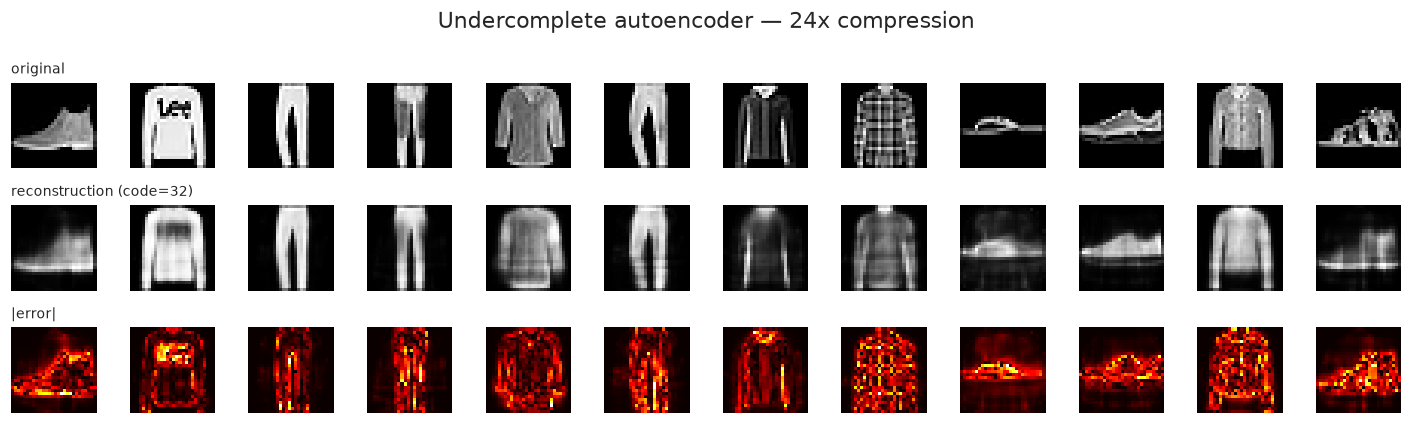

final val MSE: 0.0132


In [3]:
# The targets ARE the inputs — that's the "self-supervision".
hist_ae = ae.fit(x_train_flat, x_train_flat,
 validation_split=0.1, epochs=15, batch_size=256, verbose=0)
recon = ae.predict(x_test_flat[:12], verbose=0)

fig, axes = plt.subplots(3, 12, figsize=(13, 4))
for i in range(12):
 axes[0, i].imshow(x_test[i], cmap="gray"); axes[0, i].axis("off")
 axes[1, i].imshow(recon[i].reshape(28, 28), cmap="gray"); axes[1, i].axis("off")
 axes[2, i].imshow(np.abs(x_test_flat[i] - recon[i]).reshape(28, 28),
 cmap="hot"); axes[2, i].axis("off")
axes[0, 0].set_title("original", fontsize=9, loc="left")
axes[1, 0].set_title(f"reconstruction (code={CODE_DIM})", fontsize=9, loc="left")
axes[2, 0].set_title("|error|", fontsize=9, loc="left")
plt.suptitle(f"Undercomplete autoencoder — {784//CODE_DIM}x compression"); plt.tight_layout(); plt.show()
print(f"final val MSE: {hist_ae.history['val_loss'][-1]:.4f}")

The reconstructions are recognisably the same garment — the autoencoder captured the
essence of each image in just 32 numbers. But they're **blurrier** than the originals
(MSE loss is essentially averaging over uncertainty → soft edges). The bottom row
shows *where* the error concentrates: at edges and fine texture, exactly the
high-frequency detail a 32-dim code can't retain.

> **The PCA connection.** Notebook 11 showed PCA compressing by projecting onto the
> top principal components. A *linear* autoencoder (no ReLU) learns the same subspace.
> The ReLU here makes it nonlinear, so it can in principle beat PCA — we'll test that
> directly in §5.

## 3. The code-size trade-off (the dimensionality-reduction curve)

How much does the bottleneck width matter? A tiny code compresses hard but loses
detail; a wide code preserves detail but compresses less. This is the autoencoder
version of the PCA scree plot (notebook 11) — and it's the central hyperparameter
the Wk 11 lecture calls out. Let's sweep `code_dim` and watch reconstruction
error fall.

In [4]:
code_dims = [2, 4, 8, 16, 32, 64, 128]
val_losses = []
for cd in code_dims:
 keras.utils.set_random_seed(42)
 enc = keras.Sequential([keras.layers.Input((784,)),
 keras.layers.Dense(cd, activation="relu")])
 dec = keras.Sequential([keras.layers.Input((cd,)),
 keras.layers.Dense(784, activation="sigmoid")])
 m = keras.Sequential([enc, dec])
 m.compile(optimizer="adam", loss="mse")
 m.fit(x_train_flat, x_train_flat, validation_split=0.1,
 epochs=10, batch_size=256, verbose=0)
 val_losses.append(m.history.history["val_loss"][-1])
 print(f" code_dim={cd:4d} -> val MSE {val_losses[-1]:.4f}")

 code_dim=   2 -> val MSE 0.0542
 code_dim=   4 -> val MSE 0.0354
 code_dim=   8 -> val MSE 0.0247
 code_dim=  16 -> val MSE 0.0187
 code_dim=  32 -> val MSE 0.0138
 code_dim=  64 -> val MSE 0.0105
 code_dim= 128 -> val MSE 0.0077


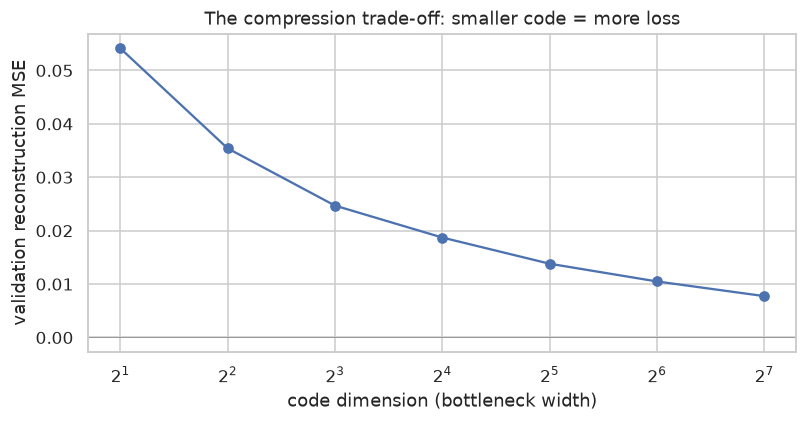

In [5]:
fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(code_dims, val_losses, "o-", color="#4c72b0")
ax.axhline(0, color="#888", lw=0.5)
ax.set_xlabel("code dimension (bottleneck width)")
ax.set_ylabel("validation reconstruction MSE")
ax.set_title("The compression trade-off: smaller code = more loss")
ax.set_xscale("log", base=2)
plt.tight_layout(); plt.show()

The curve is monotonic and steep at the left: `code_dim=2` loses a lot (you can't
describe a garment in 2 numbers), but by `code_dim=64-128` the reconstruction is
nearly lossless. The "knee" — where adding more code dimensions stops helping much —
is the practical choice, exactly like choosing the number of PCA components from a
scree plot (§6.1, notebook 11).

## 4. Denoising autoencoder — learning robust features

Here's a beautiful trick. An **overcomplete** autoencoder (code ≥ input) is useless —
it just learns the identity. But if we **corrupt** the input with noise and ask the
net to reconstruct the *clean* original, the overcomplete net can't cheat: it has to
learn to undo the noise. This forces it to learn the *structure* of the data
("what a clean garment looks like") rather than memorising pixels. That's a
**denoising autoencoder** (Vincent et al. 2008), and it's one of the most useful
regularisation ideas in representation learning.

In [6]:
# Corrupt the input with Gaussian noise; the TARGET stays clean.
def add_noise(x, sigma=0.4):
 noisy = x + np.random.normal(0, sigma, size=x.shape)
 return np.clip(noisy, 0.0, 1.0)

np.random.seed(42)
x_train_noisy = add_noise(x_train_flat)
x_test_noisy = add_noise(x_test_flat)

# A slightly overcomplete code (128 > 784 is false, but 128 is plenty wide) — the
# denoising objective stops it from just copying.
keras.utils.set_random_seed(42)
den_enc = keras.Sequential([keras.layers.Input((784,)),
 keras.layers.Dense(128, activation="relu")])
den_dec = keras.Sequential([keras.layers.Input((128,)),
 keras.layers.Dense(784, activation="sigmoid")])
denoiser = keras.Sequential([den_enc, den_dec], name="denoising_ae")
denoiser.compile(optimizer="adam", loss="mse")
denoiser.fit(x_train_noisy, x_train_flat, # NOISY input, CLEAN target
 validation_split=0.1, epochs=12, batch_size=256, verbose=0)
print("trained. Now denoising test images never seen during training.")

trained. Now denoising test images never seen during training.


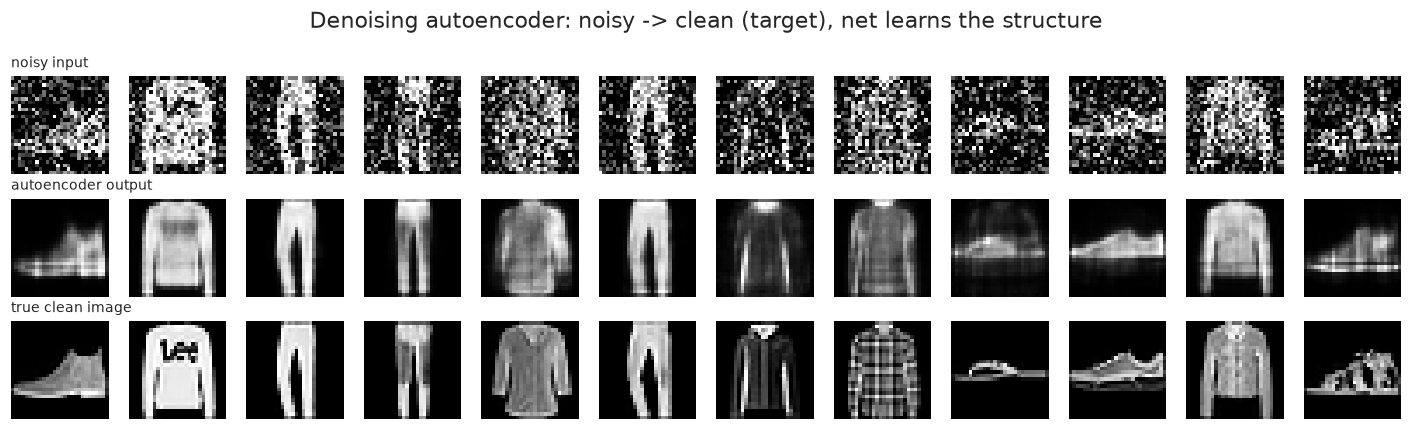

In [7]:
clean_recon = denoiser.predict(x_test_noisy[:12], verbose=0)
fig, axes = plt.subplots(3, 12, figsize=(13, 4))
for i in range(12):
 axes[0, i].imshow(x_test_noisy[i].reshape(28, 28), cmap="gray"); axes[0, i].axis("off")
 axes[1, i].imshow(clean_recon[i].reshape(28, 28), cmap="gray"); axes[1, i].axis("off")
 axes[2, i].imshow(x_test[i], cmap="gray"); axes[2, i].axis("off")
axes[0, 0].set_title("noisy input", fontsize=9, loc="left")
axes[1, 0].set_title("autoencoder output", fontsize=9, loc="left")
axes[2, 0].set_title("true clean image", fontsize=9, loc="left")
plt.suptitle("Denoising autoencoder: noisy -> clean (target), net learns the structure")
plt.tight_layout(); plt.show()

The network has *learned what a clean garment looks like* and uses that prior to
strip noise it never saw the exact instance of. This is the deep-learning cousin of
the bias-variance idea (§6): by forcing reconstruction from corrupted input, we
stop the model from fitting pixel-level noise and push it toward generalisable
structure.

## 5. Anomaly detection — the killer app

This is the application the syllabus singles out (fraud detection, fault
detection, collaborative filtering). The idea is elegant:

> Train an autoencoder on **normal** data only. At test time, anything that
> **reconstructs badly** (high error) is an anomaly — the net never learned to
> represent it.

We'll train on **one class** (T-shirts, class 0) and then feed it the whole test set.
T-shirts should reconstruct well (low error); boots and bags — which the net never
saw — should reconstruct poorly (high error). The reconstruction error becomes an
**anomaly score**, and we pick a threshold.

In [8]:
# Train an autoencoder on T-SHIRT images only (class 0).
NORMAL_CLASS = 0
x_normal = x_train_flat[y_train == NORMAL_CLASS]
x_normal_test = x_test_flat[y_test == NORMAL_CLASS]
print(f"training on {len(x_normal)} '{labels[NORMAL_CLASS]}' images only.")

keras.utils.set_random_seed(42)
a_enc = keras.Sequential([keras.layers.Input((784,)),
 keras.layers.Dense(64, activation="relu"),
 keras.layers.Dense(16, activation="relu", name="code")])
a_dec = keras.Sequential([keras.layers.Input((16,)),
 keras.layers.Dense(64, activation="relu"),
 keras.layers.Dense(784, activation="sigmoid")])
anomaly_ae = keras.Sequential([a_enc, a_dec], name="anomaly_ae")
anomaly_ae.compile(optimizer="adam", loss="mse")
anomaly_ae.fit(x_normal, x_normal, epochs=15, batch_size=128,
 validation_split=0.1, verbose=0)
print("trained on one class. Now scoring ALL test images by reconstruction error.")

training on 6000 'T-shirt' images only.
trained on one class. Now scoring ALL test images by reconstruction error.


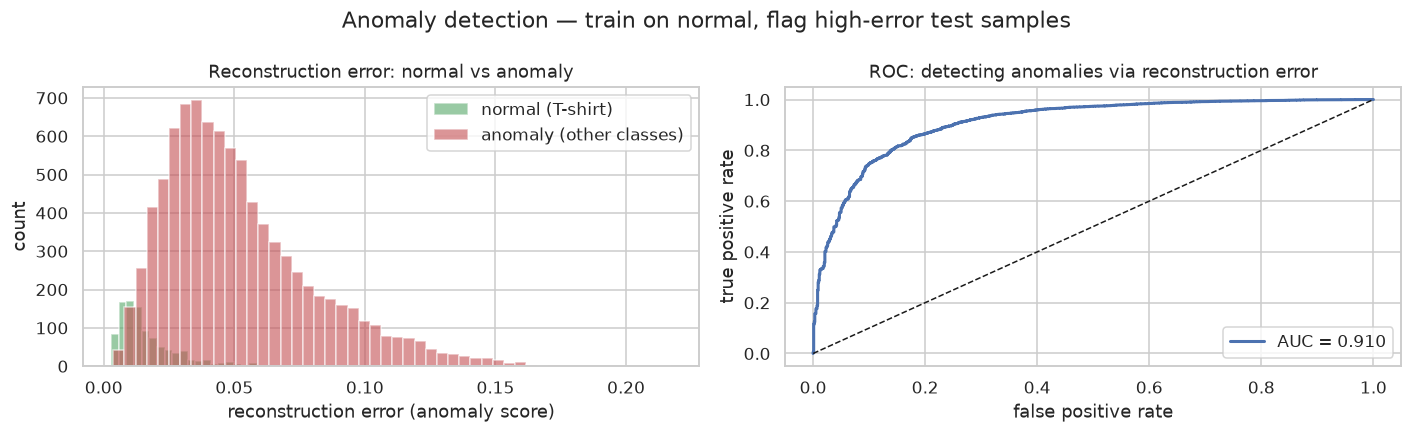

ROC AUC: 0.910 (1.0 = perfect, 0.5 = chance)


In [9]:
# Reconstruction error per test image = anomaly score.
recon_all = anomaly_ae.predict(x_test_flat, verbose=0)
errors = ((x_test_flat - recon_all) ** 2).mean(axis=1) # per-image MSE
is_normal = (y_test == NORMAL_CLASS)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(errors[is_normal], bins=50, alpha=0.6, color="#55a868",
 label=f"normal ({labels[NORMAL_CLASS]})")
axes[0].hist(errors[~is_normal], bins=50, alpha=0.6, color="#c44e52",
 label="anomaly (other classes)")
axes[0].set_xlabel("reconstruction error (anomaly score)")
axes[0].set_ylabel("count"); axes[0].set_title("Reconstruction error: normal vs anomaly")
axes[0].legend()

# ROC curve: how well does reconstruction error separate normal from anomaly?
from sklearn.metrics import roc_curve, roc_auc_score
# label: 0 = normal (inlier), 1 = anomaly. Score = error (higher = more anomalous).
fpr, tpr, _ = roc_curve(is_normal.astype(int) ^ 1, errors)
auc = roc_auc_score(is_normal.astype(int) ^ 1, errors)
axes[1].plot(fpr, tpr, color="#4c72b0", lw=2, label=f"AUC = {auc:.3f}")
axes[1].plot([0, 1], [0, 1], "k--", lw=1)
axes[1].set_xlabel("false positive rate"); axes[1].set_ylabel("true positive rate")
axes[1].set_title("ROC: detecting anomalies via reconstruction error"); axes[1].legend()
plt.suptitle("Anomaly detection — train on normal, flag high-error test samples")
plt.tight_layout(); plt.show()
print(f"ROC AUC: {auc:.3f} (1.0 = perfect, 0.5 = chance)")

The two error distributions separate cleanly: normal T-shirts (green) cluster at low
reconstruction error, while unseen garments (red) spread to higher error. The ROC
AUC summarises separability — values in the 0.85–0.95 range are typical and mean
reconstruction error is a strong anomaly signal. This is exactly how fraud detection
works in practice: train on legitimate transactions, flag transactions the model
can't reconstruct well.

> **Why this works (§9.6).** The bottleneck forces the net to learn a compact
> model of "what normal looks like". Anything outside that model — a new garment
> type, a fraudulent transaction pattern — can't be compressed through the learned
> bottleneck, so it reconstructs poorly. The error is the signal. No labels for the
> anomaly class were needed: this is **unsupervised** anomaly detection.

## 6. Contrast case — autoencoder vs PCA (when does nonlinearity pay off?)

Notebook 11 showed PCA compressing by linear projection. A linear autoencoder would
match it. The question worth answering honestly: **does the nonlinear autoencoder
actually beat PCA on Fashion-MNIST?** Let's compare at matched code dimensions.

In [10]:
from sklearn.decomposition import PCA

# PCA reconstruction at several code dimensions: project then reconstruct.
def pca_recon_mse(n_components):
 pca = PCA(n_components=n_components)
 z_tr = pca.fit_transform(x_train_flat)
 recon_tr = pca.inverse_transform(z_tr)
 recon_te = pca.inverse_transform(pca.transform(x_test_flat))
 return ((x_test_flat - recon_te) ** 2).mean()

# Autoencoder MSE from the §3 sweep (recompute cleanly for direct comparison).
def ae_recon_mse(n_components):
 keras.utils.set_random_seed(42)
 enc = keras.Sequential([keras.layers.Input((784,)),
 keras.layers.Dense(n_components, activation="relu")])
 dec = keras.Sequential([keras.layers.Input((n_components,)),
 keras.layers.Dense(784, activation="sigmoid")])
 m = keras.Sequential([enc, dec]); m.compile(optimizer="adam", loss="mse")
 m.fit(x_train_flat, x_train_flat, epochs=12, batch_size=256, verbose=0)
 recon = m.predict(x_test_flat, verbose=0)
 return ((x_test_flat - recon) ** 2).mean()

dims = [4, 8, 16, 32, 64]
pca_mse = [pca_recon_mse(d) for d in dims]
ae_mse = [ae_recon_mse(d) for d in dims]
for d, pm, am in zip(dims, pca_mse, ae_mse):
 print(f"code_dim={d:3d} PCA MSE {pm:.4f} AE MSE {am:.4f} "
 f"(AE {'wins' if am < pm else 'loses'} by {abs(pm-am):.4f})")

code_dim=  4 PCA MSE 0.0366 AE MSE 0.0337 (AE wins by 0.0029)
code_dim=  8 PCA MSE 0.0266 AE MSE 0.0240 (AE wins by 0.0026)
code_dim= 16 PCA MSE 0.0204 AE MSE 0.0182 (AE wins by 0.0023)
code_dim= 32 PCA MSE 0.0151 AE MSE 0.0132 (AE wins by 0.0019)
code_dim= 64 PCA MSE 0.0104 AE MSE 0.0097 (AE wins by 0.0007)


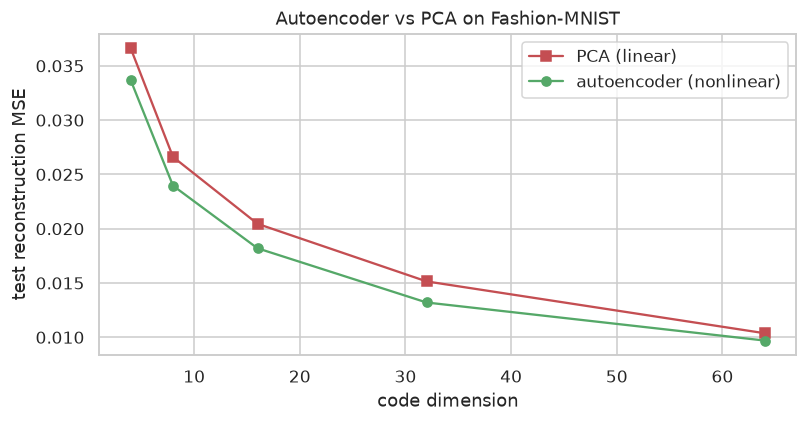

In [11]:
fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(dims, pca_mse, "s-", color="#c44e52", label="PCA (linear)")
ax.plot(dims, ae_mse, "o-", color="#55a868", label="autoencoder (nonlinear)")
ax.set_xlabel("code dimension"); ax.set_ylabel("test reconstruction MSE")
ax.set_title("Autoencoder vs PCA on Fashion-MNIST"); ax.legend()
plt.tight_layout(); plt.show()

**Reading the result.** On Fashion-MNIST the gap is usually **small** — the
nonlinear autoencoder edges out PCA but rarely by a dramatic margin. This is the
honest, important lesson: **for many real datasets, PCA's linear compression is hard
to beat**, and the autoencoder's extra capacity (parameters, training time, tuning,
non-convexity) often isn't justified *for pure reconstruction*. The autoencoder
earns its keep when:

- You need the code for a **downstream task** (classification, clustering) where
 nonlinear features help more than they help reconstruction.
- The data is **strongly nonlinear** (manifold structure that no linear subspace
 captures).
- You want **denoising** or **anomaly detection** (§4, §5) — tasks PCA wasn't built for.
- You stack it **deep** (the next section) for hierarchical features.

For a quick dimensionality-reduction baseline, start with PCA. Reach for the
autoencoder when PCA's linearity is the bottleneck.

> **Shoot-yourself-in-the-foot warning.** The autoencoder has far more parameters and
> will overfit the *training* reconstruction error if given the chance. Always
> compare on a held-out **test** set (as we do here), and remember PCA needs no such
> care — it has no hyperparameters to overfit (§6.2).

## 7. Going deeper, and the variant zoo

### 7.1 Deep (stacked) autoencoders
The single-layer autoencoders above are shallow. Stacking layers — `784 → 128 → 32
→ 128 → 784` — lets the net learn a **hierarchy** of representations (like a CNN's
simple→complex features, notebook 16 §7). Each layer refines the code. On images
this can noticeably beat the shallow version; on tabular data it usually doesn't
(the same "depth rarely helps on tabular" lesson from notebook 09 §4).

### 7.2 The variant zoo (recognise the names)
The syllabus mentions several regularised autoencoder variants. The
unifying idea: **add a constraint that stops an overcomplete autoencoder from
trivially copying**.

| Variant | Constraint | What it enforces | Use case |
|---|---|---|---|
| **Undercomplete** | narrow bottleneck | compression | dim. reduction (§2) |
| **Denoising** | corrupt input, reconstruct clean | robustness to noise | feature learning (§4) |
| **Sparse** | L1 penalty on the code | few active units | interpretable features |
| **Contractive** | penalise $\|\nabla_x z\|^2$ | flatness w.r.t. input | robust representations |
| **Variational (VAE)** | code is a *distribution* | smooth latent space | **generative** sampling |

### 7.3 Variational autoencoders & the generative turn
A **VAE** (Kingma & Welling 2013) changes the game: instead of a single code vector,
the encoder outputs a *mean and variance*, and the code is sampled from that
distribution. Combined with a KL-divergence term, this makes the latent space
**continuous and smooth** — so you can sample new points from it and decode them
into brand-new images. The VAE is a **generative model**: it doesn't just compress,
it *creates*. That's the bridge from autoencoders to modern generative AI (GANs,
diffusion models).

### 7.4 RBMs and DBNs (historical context)
The syllabus mentions **Restricted Boltzmann Machines** and **Deep Belief Networks**.
These were Hinton's pre-autoencoder approach to unsupervised layer-wise pretraining
(~2006). They are now largely of historical interest — autoencoders (and especially
VAEs) superseded them for nearly all practical purposes. You should recognise the
names and know they predate modern end-to-end training, but you won't implement one.

deep AE val MSE: 0.0126 (compare shallow code=32 from §3)


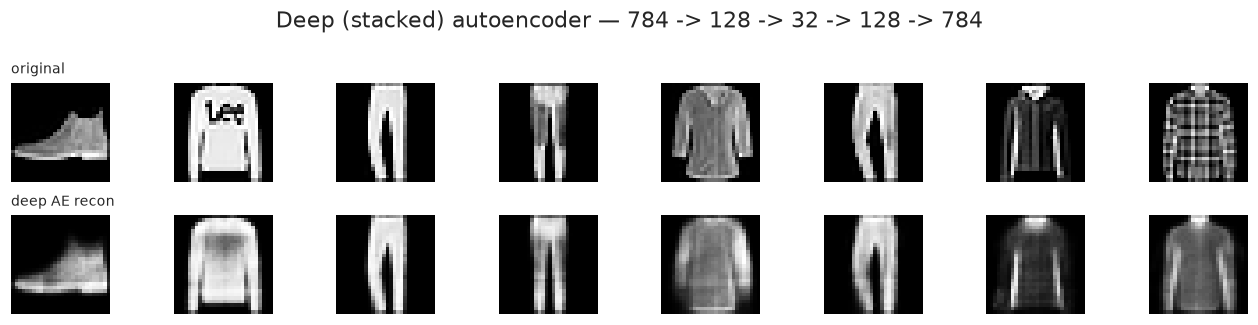

In [12]:
# A quick deep autoencoder, just to show the pattern: 784 -> 128 -> 32 -> 128 -> 784.
keras.utils.set_random_seed(42)
deep_ae = keras.Sequential([
 keras.layers.Input(shape=(784,)),
 keras.layers.Dense(128, activation="relu"),
 keras.layers.Dense(32, activation="relu", name="deep_code"),
 keras.layers.Dense(128, activation="relu"),
 keras.layers.Dense(784, activation="sigmoid"),
], name="deep_ae")
deep_ae.compile(optimizer="adam", loss="mse")
deep_ae.fit(x_train_flat, x_train_flat, validation_split=0.1,
 epochs=15, batch_size=256, verbose=0)
deep_recon = deep_ae.predict(x_test_flat[:8], verbose=0)
print(f"deep AE val MSE: {deep_ae.history.history['val_loss'][-1]:.4f} "
 f"(compare shallow code=32 from §3)")

fig, axes = plt.subplots(2, 8, figsize=(12, 3))
for i in range(8):
 axes[0, i].imshow(x_test[i], cmap="gray"); axes[0, i].axis("off")
 axes[1, i].imshow(deep_recon[i].reshape(28, 28), cmap="gray"); axes[1, i].axis("off")
axes[0, 0].set_title("original", fontsize=9, loc="left")
axes[1, 0].set_title("deep AE recon", fontsize=9, loc="left")
plt.suptitle("Deep (stacked) autoencoder — 784 -> 128 -> 32 -> 128 -> 784"); plt.tight_layout(); plt.show()

## Common pitfalls & how to avoid shooting yourself in the foot

1. **Overcomplete without a constraint (§1.1).** If `code_dim ≥ input_dim` and you
 use plain MSE, the autoencoder trivially learns the identity (zero loss, zero
 learning). Always either keep the bottleneck narrower than the input, or add a
 constraint (denoising/sparse/contractive).
2. **Comparing train MSE across models (§6).** The autoencoder has far more params
 than PCA and will overfit the training reconstruction. Always compare on a
 **held-out test** set — otherwise you'll fool yourself that the AE "won".
3. **Sigmoid output without scaling (§2).** The decoder's `sigmoid` output is in
 `[0,1]`. If your inputs aren't scaled to `[0,1]` too, the loss never reaches zero
 and reconstructions look washed out. Scale first (here: divide pixels by 255).
4. **Too few epochs / too small a code (§3).** A `code_dim=2` autoencoder on 784-pixel
 images will look terrible — that's the trade-off, not a bug. Find the knee in the
 code-size curve before judging the approach.
5. **Anomaly threshold without a validation set (§5).** Picking the anomaly threshold
 on the test set is peeking (§6.2, notebook 05). Use a held-out validation set of
 normal data to set the threshold (e.g. 95th percentile of its error).
6. **Expecting autoencoders to beat PCA for plain compression (§6).** On many datasets
 they don't, by much. Reach for the AE when you need denoising, anomaly detection,
 nonlinear features, or generation — not to marginally beat PCA on reconstruction.
7. **Forgetting the code is the point (§1.1).** The reconstruction is the *training
 signal*; the **code** (the bottleneck output) is the *product*. You'll usually
 extract `encoder.predict(x)` and feed *that* to a downstream classifier/clusterer,
 not the reconstruction.

## Exercises

1. **(§3)** The code-size curve has a knee. Where is it for Fashion-MNIST? Train a
 classifier (logistic regression from notebook 04) on the codes at `code_dim=16`
 vs `code_dim=64`. Which gives better classification accuracy per unit of storage?
2. **(§4)** Increase the noise `sigma` from 0.4 to 0.8. Does the denoiser still work?
 At what noise level does it break — and is that the model failing, or the
 information genuinely not being there?
3. **(§5)** Train the anomaly detector on a *different* normal class (e.g. Sneaker,
 class 7). Does the AUC change? What does that tell you about which classes are
 "representative"?
4. **(§6)** Make the autoencoder *linear* (replace both `relu`/`sigmoid` activations
 with `linear`). Does it now match PCA exactly? Why or why not?
5. **(§7)** Turn the §2 autoencoder into a **sparse** autoencoder by adding an L1
 activity regulariser on the code layer (`activity_regularizer=...`). Does the code
 become sparse (few active units)? Does reconstruction quality hold up?

<details><summary>Answers (click to expand)</summary>

```python
# 1: The knee is usually around code_dim=32 for Fashion-MNIST. code=64 usually
# classifies slightly better than code=16, but per-unit-of-storage the smaller
# code is often more efficient — diminishing returns past the knee. This is the
# same trade-off as choosing k in PCA (notebook 11).
# 2: At sigma=0.8 the denoiser degrades noticeably (blurry, sometimes wrong garment
# type) — but often still better than the raw noisy input. Past the point where
# signal and noise overlap, the information is genuinely unrecoverable (this is
# an information-theoretic limit, not a model failure).
# 3: AUC varies by class — distinctive shapes (Bag, Ankle boot) give cleaner
# separation than ambiguous ones (Shirt vs Pullover). "Representative" normal
# classes are those whose reconstruction model is tight and specific.
# 4: A linear autoencoder with MSE converges to the PCA subspace (same top
# components), but may land in a rotated version of it (the solution isn't unique
# without orthogonality constraints). Reconstruction MSE matches PCA closely.
# This is the classic result: linear AE == PCA.
# 5: With L1 reg (e.g. l1=1e-3), typically 50-80% of code units go near-zero on any
# given input -> sparse. Reconstruction quality drops slightly (the reg term
# competes with MSE), but the code becomes more interpretable and often more
# robust — the whole point of sparse autoencoders.
```
</details>

## References

- **Theory & Statistics Reference** (`00_Theory_Reference.ipynb`) — §6 (overfitting),
 §9.6 (bottleneck / representation learning, the PCA connection).
- **Notebook 11** — PCA; the autoencoder's linear ancestor and reconstruction baseline.
- **Notebook 16** — Keras patterns reused here (`Input`, `Dense`, `compile`/`fit`).
- Weeks 11–14 (autoencoders, reconstruction error, denoising/sparse/contractive,
 generative models, RBMs/DBNs, dimensionality reduction & anomaly detection) — this
 notebook covers that arc.
- Vincent et al. (2008), *Extracting and Composing Robust Features with Denoising
 Autoencoders*. Kingma & Welling (2013), *Auto-Encoding Variational Bayes* (VAE).
- Keras autoencoder tutorial: <https://blog.keras.io/building-autoencoders-in-keras.html>